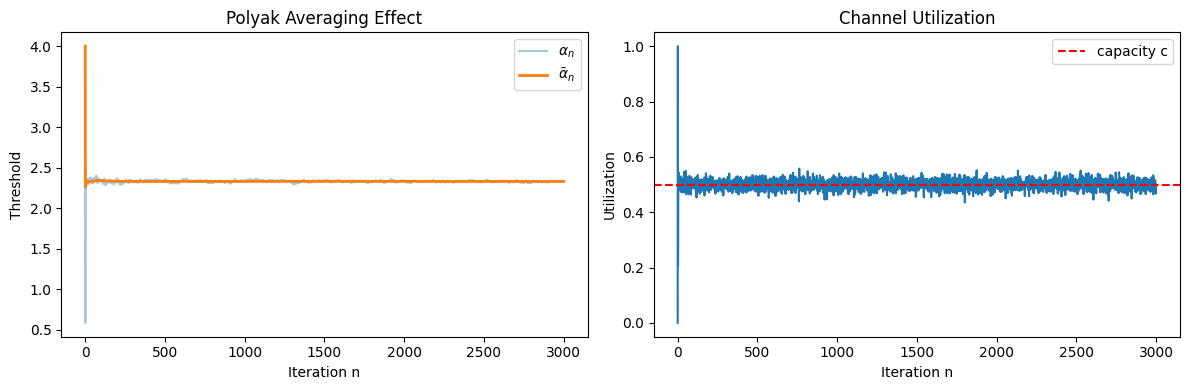

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SYSTEM PARAMETERS
# =========================
N = 4
r = np.array([100, 50, 10, 1])
p = np.array([1/3, 1/12, 1/4, 1/3])
λ = 1e5
c = 0.5

ε0 = 10
γ = 0.55
T = 0.01
N_iter = 3000

# =========================
# THRESHOLD POLICY
# =========================
def admit(α, j):
    k = int(np.floor(α))
    if j < k:
        return 1
    elif j == k:
        return np.random.rand() < (α - k)
    else:
        return 0

# =========================
# ROBBINS–MONRO + POLYAK
# =========================
α = 0.0
α_bar = 0.0   # Polyak average

α_history = []
α_bar_history = []
Z_history = []

for n in range(1, N_iter + 1):

    ε_n = ε0 / (n ** γ)

    arrivals = np.random.poisson(λ * T)
    admitted = 0

    for _ in range(arrivals):
        j = np.random.choice(N, p=p)
        admitted += admit(α, j)

    Z_n = admitted / arrivals if arrivals > 0 else 0.0

    # Robbins–Monro update
    α = α + ε_n * (c - Z_n)
    α = np.clip(α, 0, N)

    # Polyak averaging
    α_bar = α_bar + (α - α_bar) / n

    α_history.append(α)
    α_bar_history.append(α_bar)
    Z_history.append(Z_n)

# =========================
# PLOTS
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(α_history, alpha=0.4, label=r"$\alpha_n$")
plt.plot(α_bar_history, linewidth=2, label=r"$\bar{\alpha}_n$")
plt.xlabel("Iteration n")
plt.ylabel("Threshold")
plt.legend()
plt.title("Polyak Averaging Effect")

plt.subplot(1, 2, 2)
plt.plot(Z_history)
plt.axhline(c, color="red", linestyle="--", label="capacity c")
plt.xlabel("Iteration n")
plt.ylabel("Utilization")
plt.legend()
plt.title("Channel Utilization")

plt.tight_layout()
plt.show()
